# Two-category GMVAE with one shared continuous auxiliary variable

This notebook adds **one shared vector-valued $w$** to the existing phoneme/speaker model and runs it on exactly the same selected vowel dataset. It calls the new `SharedWGMVAE` class in `models.py`; the previous `TwoFactorVaDE`, classifier, baseline config, and `train_vowels.ipynb` are preserved.

Reference: Dilokthanakul et al., *Deep Unsupervised Clustering with Gaussian Mixture Variational Autoencoders*, arXiv:1611.02648v2, sections 3.1–3.4, Eq. (1), (3)–(5), (7), and Appendix A. The supplied PDF is `E:/Downloads/1611.02648v2 (1).pdf`. The reference informs the model design; it is not needed to execute this notebook.

## 1. What changes when we add $w$?

| Quantity | Paper notation | Project notation |
|---|---|---|
| Observed acoustic vector | $y$ | $x$ (five features) |
| Continuous acoustic latent | $x$ | $z$ (8 dimensions) |
| Mixture category | $z$ | $(c_\phi,c_s)$ (5 × 10 combinations) |
| Auxiliary continuous latent | $w$ | $w$ (default: 2 dimensions) |

The proposed generative model is

$$w\sim\mathcal N(0,I),\quad c_\phi\sim\mathrm{Cat}(\pi_\phi),\quad c_s\sim\mathrm{Cat}(\pi_s),$$
$$z\mid w,c_\phi=i,c_s=j\sim\mathcal N(\mu_{ij}(w),\mathrm{diag}\,\sigma^2_{ij}(w)),\qquad x\mid z\sim p_\theta(x\mid z).$$

There is **one $w$ sample per token**, supplied to all 50 mixture components. We do not introduce separate $w_\phi$ and $w_s$, or one global latent shared by the entire dataset. A single random variable can be a vector; set `w_dim=1` for a scalar.

The change is localized, but not just one extra output. It requires two posterior heads for $q(w\mid x)$, a network producing conditional mixture parameters, responsibilities $p(c_\phi,c_s\mid z,w)$, and the Gaussian KL penalty for $w$. The decoder, acoustic latent size, category counts, preprocessing, split, training budget, and evaluation mapping are kept the same.

## 2. Load editable configuration (Anaconda)

Select the `lffl` Anaconda interpreter used for the baseline. The default config inherits `configs/vowels.py` and changes only the new-model settings, method name, and output directory. `objective='paper'` follows the paper's Eq. (5) estimator; the distinction from the exact structured ELBO is explained below.

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict
from pprint import pprint

ROOT = Path.cwd().resolve()
if not (ROOT / 'metadata_vowels_acoustics.csv').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src' / 'configs' / 'shared_w.py').exists()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import load_config
config = load_config(ROOT / 'src' / 'configs' / 'shared_w.py')
# Editable overrides; put permanent changes in src/configs/shared_w.py:
# config.model.w_dim = 1
# config.model.objective = 'structured'
# config.training.epochs = 150
# config.training.device = 'cuda'
print('Python:', sys.executable)
pprint(asdict(config))

Python: C:\Users\46021\.conda\envs\lffl\python.exe
{'data': {'csv_path': 'metadata_vowels_acoustics.csv',
          'features': ('f0_median_hz', 'f1_hz', 'f2_hz', 'f3_hz', 'duration_s'),
          'log_features': False,
          'n_speakers': 10,
          'seed': 2026,
          'speaker_ids': None,
          'split': (0.8, 0.1, 0.1)},
 'knn_neighbors': 15,
 'methods': ('gmvae_shared_w',),
 'model': {'eval_mc_samples': 32,
           'hidden_dims': (128, 128),
           'interaction_weight': 10.0,
           'latent_dim': 8,
           'learn_mixture_weights': False,
           'objective': 'paper',
           'observation_variance': 0.1,
           'prior_hidden_dims': (64,),
           'train_mc_samples': 4,
           'w_dim': 2},
 'output_dir': 'outputs/shared_w',
 'training': {'batch_size': 512,
              'device': 'cpu',
              'epochs': 100,
              'grad_clip': 10.0,
              'learning_rate': 0.001,
              'min_delta': 0.0001,
              'num_

## 3. Prepare and verify the same data

Inputs: median f0, F1, F2, F3, and duration. All tokens from the same ten randomly selected speakers are retained. The 80/10/10 split is stratified by speaker × phoneme and operates on tokens, so speakers and potentially recordings are represented across splits. Missing/invalid values are imputed and standardized using training statistics only.

If the saved baseline run is available, verify the source CSV hash, speaker list, preprocessing settings, and every split assignment before comparing its results. For a new server without those outputs, training still works; the notebook simply omits the historical comparison.

In [2]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from src.data import prepare_data

vowels = prepare_data(config.data)
print('Speakers:', vowels.speakers)
print('Counts:', vowels.metadata['split_counts'])
assert np.array_equal(np.sort(np.concatenate(list(vowels.indices.values()))), np.arange(len(vowels.frame)))
assert all(np.isfinite(x).all() for x in vowels.x.values())

baseline_dir = ROOT / 'outputs' / 'vowels' / '20260924_164535_c90671'
baseline_available = (baseline_dir / 'summary.csv').exists()
if baseline_available:
    baseline_data = json.loads((baseline_dir / 'data.json').read_text(encoding='utf-8'))
    for key in ('csv_sha256', 'features', 'log_features', 'speakers', 'phonemes',
                'imputation_medians', 'scaler_mean', 'scaler_scale'):
        assert vowels.metadata[key] == baseline_data[key], key
    current_manifest = vowels.frame[['source_row', 'speaker_id', 'label']].copy()
    for part, indices in vowels.indices.items():
        current_manifest.loc[indices, 'split'] = part
    pd.testing.assert_frame_equal(current_manifest, pd.read_csv(baseline_dir / 'split_manifest.csv'))
    print('Verified: baseline and new model use identical data and split assignments.')
else:
    print('Saved baseline is unavailable here; this run will stand alone.')
display(pd.crosstab(vowels.frame.speaker_id, vowels.frame.label))

Speakers: ['jvs003', 'jvs009', 'jvs018', 'jvs036', 'jvs037', 'jvs038', 'jvs046', 'jvs061', 'jvs065', 'jvs078']
Counts: {'train': 36866, 'val': 4608, 'test': 4609}


Verified: baseline and new model use identical data and split assignments.


label,a,e,i,o,u
speaker_id,,,,,
jvs003,1128,647,783,1191,835
jvs009,1147,660,785,1204,842
jvs018,1157,668,811,1233,859
jvs036,1136,658,780,1216,830
jvs037,1087,648,786,1179,828
jvs038,1112,634,783,1174,850
jvs046,1132,658,784,1198,820
jvs061,1131,663,783,1213,838
jvs065,1154,646,787,1178,865


## 4. Network and two-factor prior

Appendix A of the paper shares encoder hidden layers between the two Gaussian posteriors. We do the same: the existing `5 → 128 → 128` encoder now has four heads $(\mu_z,\log\sigma_z^2,\mu_w,\log\sigma_w^2)$. The decoder remains `8 → 128 → 128 → 5`; it receives only $z$.

The new prior network is `w → 64 tanh → 2 × 5 × 10 × 8` outputs, providing mean and log-variance residuals on the old static mixture. Initially its final head is zero, so it reproduces the old conditional-independent prior exactly. All new parameters can learn during training.

At every $w$, the means admit the two-factor decomposition

$$\mu_{ij}(w)=\mu_0(w)+a_i(w)+b_j(w)+\widetilde h_{ij}(w),$$

where row/column effects are centered and the interaction is double-centered. The regularizer is $10\,\mathbb E_{q(w\mid x)}\operatorname{mean}_{ij,d}(\widetilde h_{ij}(w)^2)$. It includes **both static and generated interaction**, so the conditional network cannot avoid the penalty through unpenalized mean interactions. Component diagonal variances can depend on $w$ just as the paper's mixture variances do; their category interactions are not penalized, matching the earlier mean-only regularization choice.

This is a structured two-category extension of the paper's flat mixture, not a claim that its labels will become semantically identifiable.

In [3]:
import torch
from src.models import SharedWGMVAE
from src.training import seed_everything

seed_everything(config.training.seed, config.training.num_threads)
model = SharedWGMVAE(len(config.data.features), len(vowels.phonemes), len(vowels.speakers), config.model)
print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
with torch.no_grad():
    w = torch.randn(3, config.model.w_dim)
    means, logvars, interactions = model.conditional_parameters(w)
    print('Conditional prior shape:', tuple(means.shape))
    assert torch.allclose(means[0], means[1])  # Static mixture at initialization.
    q = model.category_probabilities(torch.from_numpy(vowels.x['train'][:8]),
                                    torch.Generator().manual_seed(0))
    assert torch.allclose(q.sum((1, 2)), torch.ones(8))
    print('Posterior shape:', tuple(q.shape))

SharedWGMVAE(
  (encoder): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (z_mean): Linear(in_features=128, out_features=8, bias=True)
  (z_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
    )
    (1): Linear(in_features=128, out_features=5, bias=True)
  )
  (w_mean): Linear(in_features=128, out_features=2, bias=True)
  (w_logvar): Linear(in_features=128, out_features=2, bias=True)
  (prior_network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
  )
  (prior_head): Linear(in_features=64, out_features=800, bias=True)
)
Trainable parameters: 91289
Conditional prior shape: (3, 5, 10, 8)
Posterior shape: (8, 5

## 5. Training objective: paper estimator versus exact structured ELBO

The paper's recognition factorization, translated into our notation, is

$$q(z,w,c_\phi,c_s\mid x)=q(z\mid x)q(w\mid x)\,r_{ij}(z,w),$$
$$r_{ij}(z,w)=\frac{\pi_{\phi,i}\pi_{s,j}\,\mathcal N(z;\mu_{ij}(w),\Sigma_{ij}(w))}{\sum_{i',j'}\pi_{\phi,i'}\pi_{s,j'}\,\mathcal N(z;\mu_{i'j'}(w),\Sigma_{i'j'}(w))}.$$

**Default `objective='paper'`.** Implement Eq. (5) literally as the conditional-prior estimator:

$$\frac1M\sum_{m=1}^M\sum_{ij}r_{ij}(z^{(m)},w^{(m)})\,\mathrm{KL}\big[q(z\mid x)\Vert p(z\mid w^{(m)},i,j)\big].$$

Add reconstruction NLL, sample-wise categorical KL to the factorized prior, analytic $\mathrm{KL}[q(w\mid x)\Vert\mathcal N(0,I)]$, and the existing interaction penalty. Both continuous variables use reparameterized sampling; all 50 categories are enumerated, never sampled. Training uses 4 samples and evaluation averages over 32. No supervision, MI reward, KL annealing, or minimum-information threshold is added.

**Mathematical qualification.** Because $r_{ij}$ depends on the sampled $z$, weighting an analytic Gaussian KL this way is not generally the exact ELBO of the stated structured posterior. We label it the paper's estimator rather than silently equating it with that exact bound.

**Optional `objective='structured'`.** The exact negative ELBO can instead be estimated by

$$\mathbb E_{q(z\mid x)q(w\mid x)}[-\log p(x\mid z)+\log q(z\mid x)-\log\sum_{ij}\pi_{\phi,i}\pi_{s,j}p(z\mid w,i,j)] + \mathrm{KL}[q(w\mid x)\Vert\mathcal N(0,I)].$$

The code calculates the equivalent responsibility-weighted log-density term plus categorical KL, and a numerical test verifies equality to the `logsumexp` expression using identical samples. In this mode the finite-sample conditional-prior term can be negative; it is not an analytic per-component KL.

The old model averages responsibilities before applying categorical KL, whereas the paper applies categorical KL per sample. Thus a performance difference is **not a perfectly isolated causal estimate of adding $w$**. A controlled estimator-matched ablation would be a separate experiment. The current default prioritizes the requested paper-style model while keeping other settings fixed.

## 6. Train the new model

Use the same 20-epoch deterministic autoencoder initialization followed by unlabeled residual KMeans on training latents. The new posterior starts at $q(w\mid x)=\mathcal N(0,I)$ and the conditional prior initially equals the original static prior. Then all parameters train jointly for up to 100 epochs using Adam and validation early stopping. The model is restored to its best validation checkpoint.

Each run uses a fresh directory under `outputs/shared_w/`. Old models are not retrained or overwritten. Hungarian category-label alignment is learned on training predictions and held fixed for validation/test scoring.

In [4]:
from src.experiment import run_experiment

run_dir = run_experiment(config, data=vowels)
print('Saved run:', run_dir)

Run: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\shared_w\20260924_222534_4c40ff
Speakers: jvs003, jvs009, jvs018, jvs036, jvs037, jvs038, jvs046, jvs061, jvs065, jvs078
Rows: {'train': 36866, 'val': 4608, 'test': 4609}


Training gmvae_shared_w...


  autoencoder   1: MSE=0.31799


  autoencoder  10: MSE=0.00042


  autoencoder  20: MSE=0.00035


...

  gmvae_shared_w 100: train=6.0572 val=6.0966


  early stopping at 100; best epoch 80


  test: phoneme=38.468%, speaker=19.852%


        method split  phoneme_accuracy  speaker_accuracy  joint_accuracy  phoneme_balanced_accuracy  speaker_balanced_accuracy
gmvae_shared_w   val          0.372179          0.206597        0.080512                   0.348716                   0.206784
gmvae_shared_w  test          0.384682          0.198525        0.080929                   0.362114                   0.198951


Saved run: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\shared_w\20260924_222534_4c40ff


## 7. Compare held-out recognition with the existing results

Both category accuracies use the same test tokens and train-fitted mapping policy. Baseline 15-NN and the classifier are supervised; both GMVAE variants are unsupervised. These are single-seed runs, and an extra continuous variable does not guarantee improved categorical recovery.

,phoneme_accuracy,speaker_accuracy,joint_accuracy,phoneme_balanced_accuracy,speaker_balanced_accuracy
method,,,,,
gmvae,0.564982,0.213929,0.122152,0.537840,0.213173
knn,0.825776,0.497939,0.447603,0.812892,0.497461
classifier,0.839445,0.491864,0.439575,0.827534,0.491522
gmvae_shared_w,0.384682,0.198525,0.080929,0.362114,0.198951


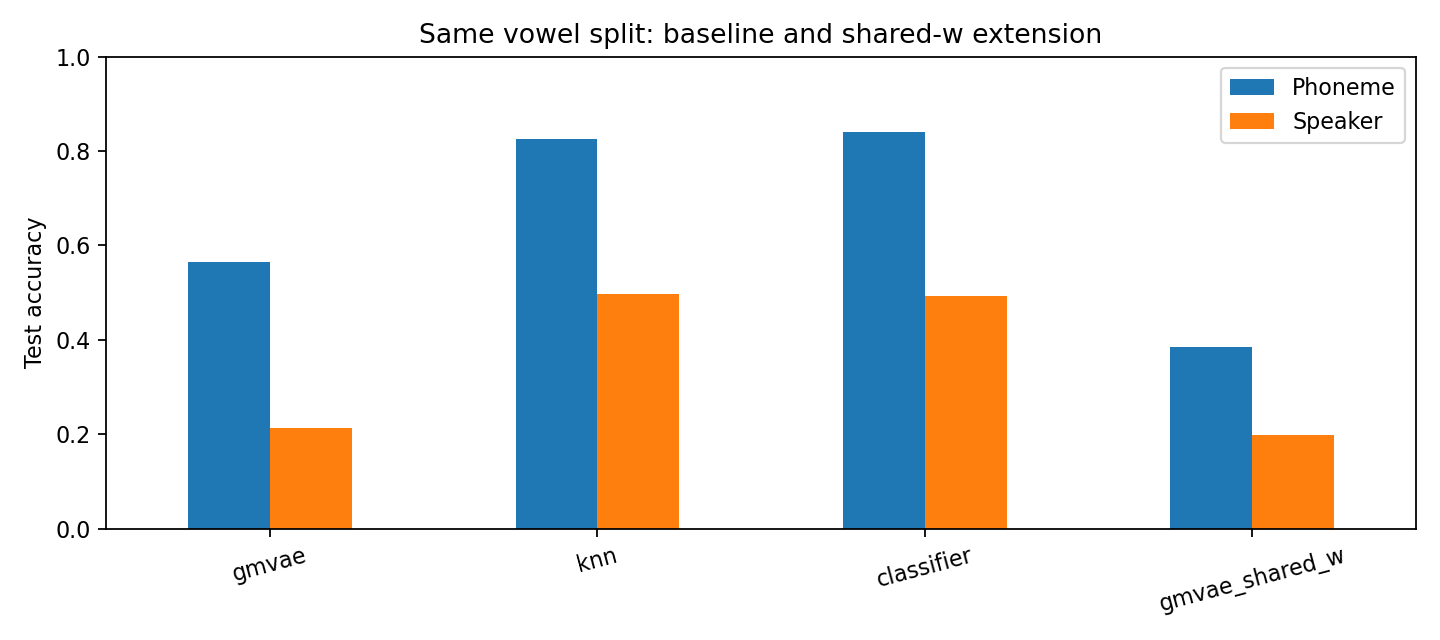

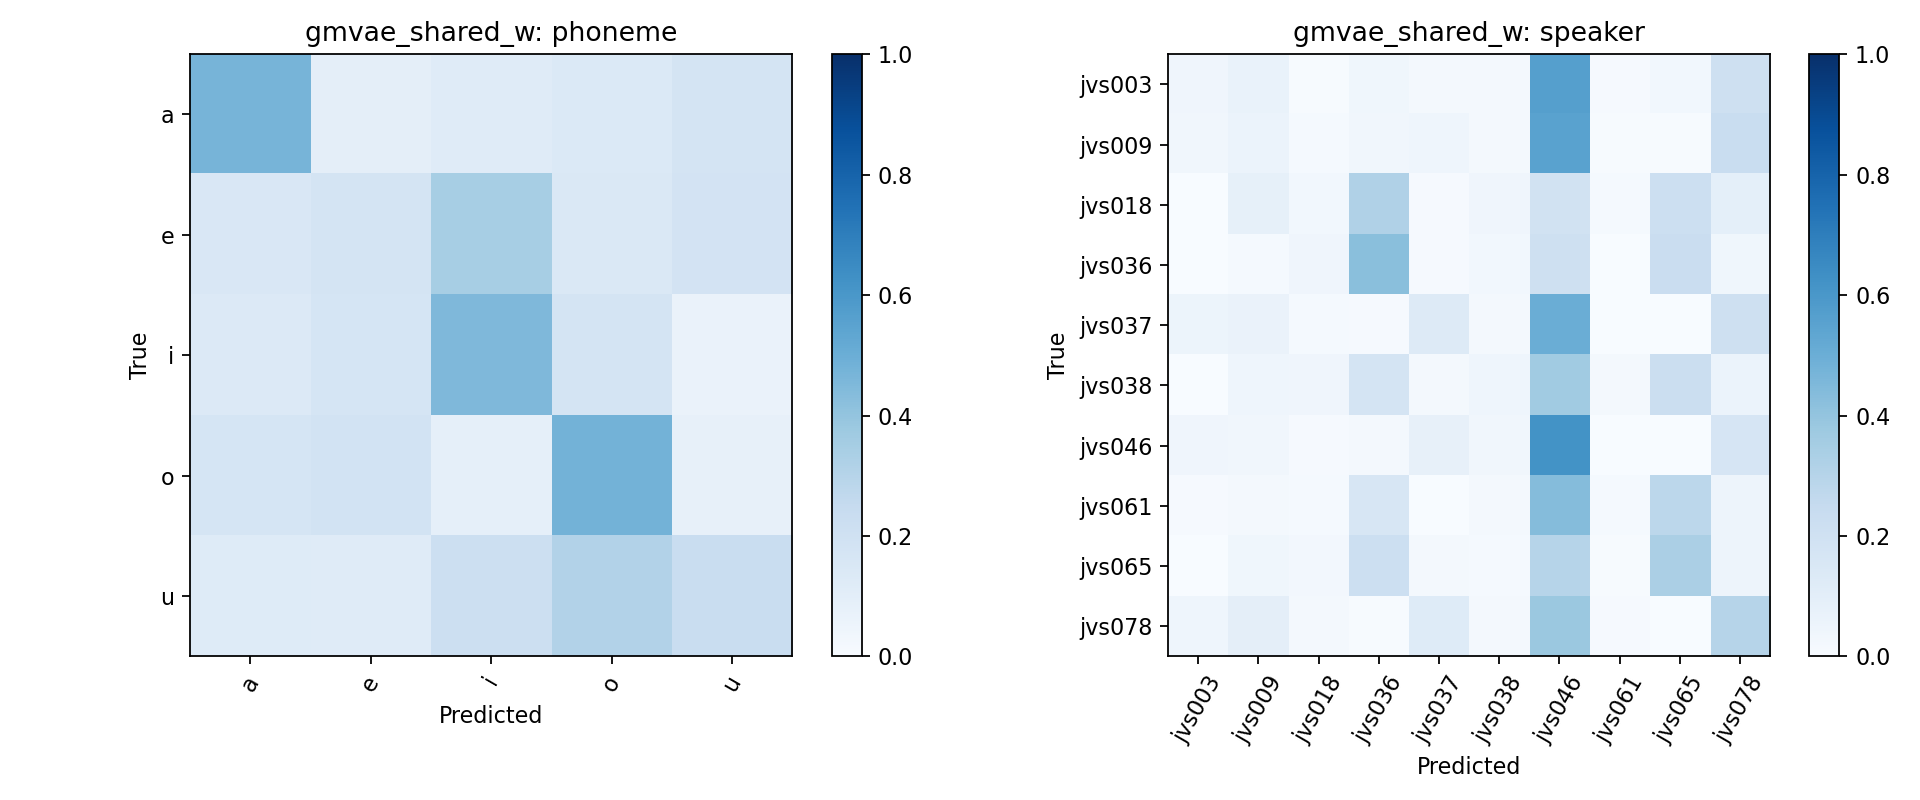

In [5]:
new_summary = pd.read_csv(run_dir / 'summary.csv')
comparison = new_summary[new_summary['split'] == 'test'].copy()
if baseline_available:
    old_summary = pd.read_csv(baseline_dir / 'summary.csv')
    comparison = pd.concat([old_summary[old_summary['split'] == 'test'], comparison], ignore_index=True)
comparison.to_csv(run_dir / 'baseline_comparison.csv', index=False)
display(comparison.set_index('method').drop(columns='split'))

import matplotlib.pyplot as plt
ax = comparison.set_index('method')[['phoneme_accuracy', 'speaker_accuracy']].plot.bar(figsize=(9, 4), rot=15)
ax.set(ylim=(0, 1), ylabel='Test accuracy', xlabel='', title='Same vowel split: baseline and shared-w extension')
ax.legend(['Phoneme', 'Speaker'])
ax.figure.tight_layout()
ax.figure.savefig(run_dir / 'baseline_comparison.png', dpi=160)
plt.close(ax.figure)
display(Image(filename=str(run_dir / 'baseline_comparison.png')))
display(Image(filename=str(run_dir / 'gmvae_shared_w' / 'confusion_matrices.png')))

## 8. Check whether the new variable is being used

The $w$ KL, posterior mean variation across tokens, and prior sensitivity to $w$ help detect an unused auxiliary variable. None proves that $w$ encodes any particular acoustic or semantic factor. The model can also put information in $w$ without making either discrete factor more useful.

The paper itself discusses category collapse and a minimum-information threshold (Eq. 7). We do not enable that modification in this first comparison, because it would add a separate experimental change.

Best epoch: 80
Held-out w diagnostics:
{'kl_per_dimension_nats': [4.925749090034515e-05, 0.013003858737647533],
 'mean_kl_to_standard_normal_nats': 0.013053102418780327,
 'mean_posterior_std': [1.000040054321289, 0.9802573919296265],
 'posterior_mean_std_across_tokens': [0.009629235602915287,
                                      0.15628769993782043],
 'prior_logvar_change_rms_at_plus_minus_unit_w': 0.040882524102926254,
 'prior_mean_change_rms_at_plus_minus_unit_w': 0.04687425121665001}
Discrete category diagnostics:


,conditional_entropy_nats,mutual_information_nats,active_argmax_categories
phoneme,1.448504,0.160852,5.0
speaker,1.899019,0.403418,10.0
joint,3.334191,0.577315,50.0


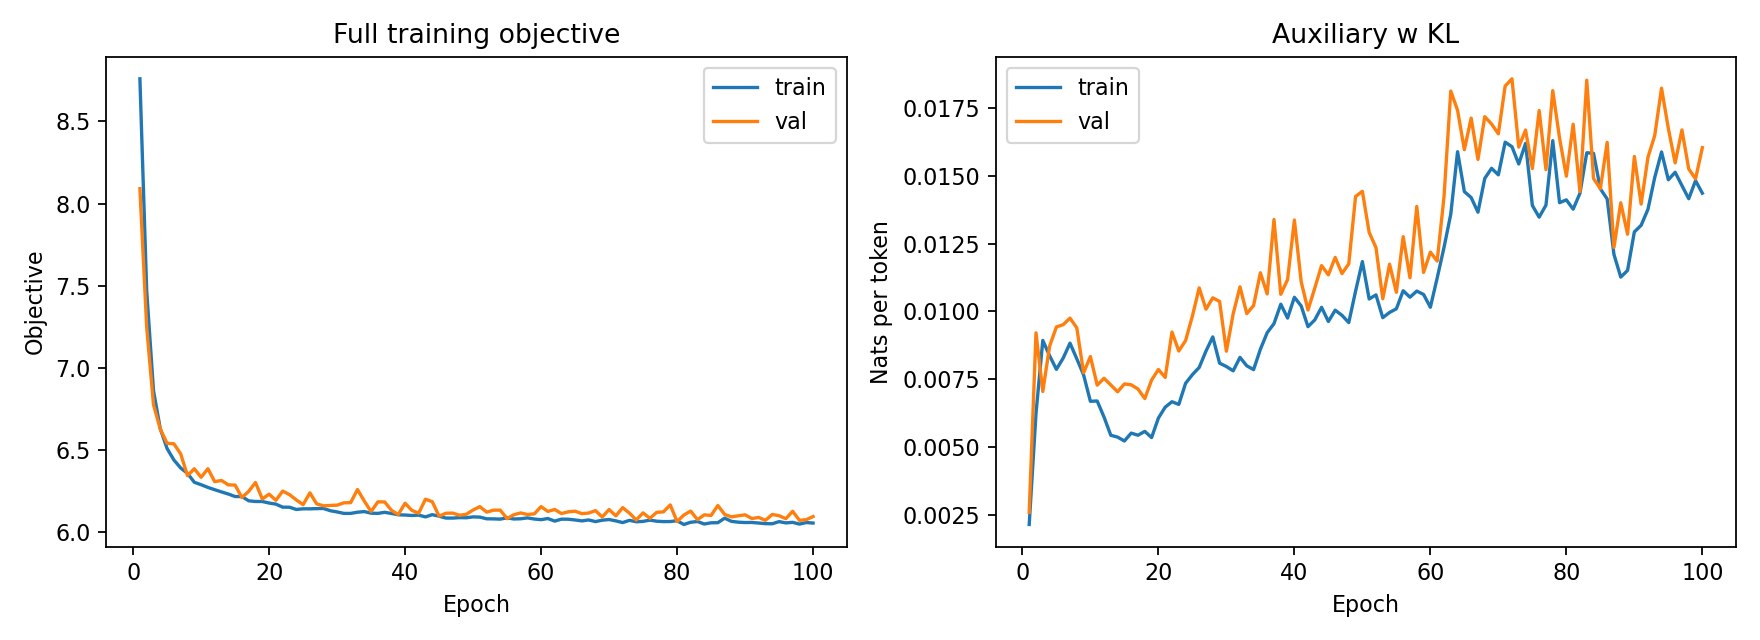

In [6]:
metrics = json.loads((run_dir / 'gmvae_shared_w' / 'metrics.json').read_text(encoding='utf-8'))
print('Best epoch:', metrics['best_epoch'])
print('Held-out w diagnostics:')
pprint(metrics['test']['w_diagnostics'])
print('Discrete category diagnostics:')
display(pd.DataFrame({name: {k: v for k, v in values.items() if k != 'mean_probabilities'}
                      for name, values in metrics['test']['mixture_diagnostics'].items()}).T)

history = pd.read_csv(run_dir / 'gmvae_shared_w' / 'history.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for part in ('train', 'val'):
    axes[0].plot(history.epoch, history[f'{part}_loss'], label=part)
    axes[1].plot(history.epoch, history[f'{part}_w_kl'], label=part)
axes[0].set(title='Full training objective', xlabel='Epoch', ylabel='Objective')
axes[1].set(title='Auxiliary w KL', xlabel='Epoch', ylabel='Nats per token')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(run_dir / 'shared_w_learning.png', dpi=160)
plt.close(fig)
display(Image(filename=str(run_dir / 'shared_w_learning.png')))

## 9. Reload the new checkpoint and verify predictions

The checkpoint records all new settings, and preprocessing remains in the run's `preprocessing.joblib`. Category vocabularies and train-fitted mappings are saved alongside it. Load only trusted checkpoint/joblib files.

In [7]:
from src.config import SharedWModelConfig
from src.evaluation import predict_neural

checkpoint = torch.load(run_dir / 'gmvae_shared_w' / 'best.pt', map_location='cpu', weights_only=True)
restored = SharedWGMVAE(checkpoint['input_dim'], len(checkpoint['phonemes']), len(checkpoint['speakers']),
                       SharedWModelConfig(**checkpoint['model_config']))
restored.load_state_dict(checkpoint['state_dict'])
restored.eval()
predicted, _ = predict_neural(restored, 'gmvae_shared_w', vowels.x['test'],
                              config.training.batch_size, config.training.seed + 200)
saved = pd.read_csv(run_dir / 'gmvae_shared_w' / 'test_predictions.csv')
assert np.array_equal(predicted, saved[['raw_category_1', 'raw_category_2']].to_numpy())
print('Checkpoint reload reproduces every saved test category prediction.')
print('Artifacts:', run_dir)

C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Checkpoint reload reproduces every saved test category prediction.
Artifacts: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\shared_w\20260924_222534_4c40ff


## Repeat from the command line or move to a server

```bash
conda activate lffl
python src/train.py --config src/configs/shared_w.py
```

For notebook execution with the current Anaconda environment:

```bash
python src/execute_notebook.py src/train_shared_w.ipynb
```

The original workflow remains `python src/train.py --config src/configs/vowels.py`. To study the exact structured ELBO, copy the new config and set `CONFIG.model.objective = 'structured'` with a distinct output directory. The numerical checks run with `python -m unittest discover -s src/tests -v`.